<a href="https://colab.research.google.com/github/Omkar210/Statistics-and-ML/blob/main/Day4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd

In [ ]:
import os
print(os.getcwd())
os.chdir('/content/drive/MyDrive/CDAC')
os.getcwd()

'/content/drive/MyDrive/CDAC'

In [ ]:
df = pd.read_excel('CDAC_DataBook.xlsx', sheet_name='ERPData')
df.head()

,MaterialID,Location,Quantity
0,TMI-43T,MWH-4,34
1,AXCP-78,MWH-1,67
2,LXCV-21,MWH-2,27
3,AXCP-78,MWH-5,65
4,AXCP-78,MWH-4,36


In [ ]:
grp1 = df.groupby('MaterialID')
grp1.groups
grp1.get_group('DDBN-89')

,MaterialID,Location,Quantity
22,DDBN-89,MWH-4,48
23,DDBN-89,MWH-5,71
26,DDBN-89,MWH-1,57
30,DDBN-89,MWH-4,27
40,DDBN-89,MWH-1,34
43,DDBN-89,MWH-3,38
45,DDBN-89,MWH-2,69
49,DDBN-89,MWH-1,39


In [ ]:
grp1.Quantity.agg('sum')

,Quantity
MaterialID,
AXCP-78,898
DDBN-89,383
GCVB-79,182
LXCV-21,243
SDRT-67,294
TMI-43T,885


## Multiple-Grouping (Using groupby command)

In [ ]:
grp1 = df.groupby(['Location','MaterialID'])
grp1.groups

{('MWH-1', 'AXCP-78'): [1, 24, 25, 39, 48], ('MWH-1', 'DDBN-89'): [26, 40, 49], ('MWH-1', 'SDRT-67'): [10, 41], ('MWH-1', 'TMI-43T'): [9], ('MWH-2', 'AXCP-78'): [46], ('MWH-2', 'DDBN-89'): [45], ('MWH-2', 'GCVB-79'): [8, 15, 35, 36], ('MWH-2', 'LXCV-21'): [2], ('MWH-2', 'SDRT-67'): [42], ('MWH-2', 'TMI-43T'): [7], ('MWH-3', 'AXCP-78'): [47], ('MWH-3', 'DDBN-89'): [43], ('MWH-3', 'LXCV-21'): [44], ('MWH-3', 'TMI-43T'): [14], ('MWH-4', 'AXCP-78'): [4], ('MWH-4', 'DDBN-89'): [22, 30], ('MWH-4', 'SDRT-67'): [11], ('MWH-4', 'TMI-43T'): [0, 5, 6, 12, 13, 18, 19, 20, 21, 31, 32], ('MWH-5', 'AXCP-78'): [3, 37, 38], ('MWH-5', 'DDBN-89'): [23], ('MWH-5', 'GCVB-79'): [34], ('MWH-5', 'LXCV-21'): [27, 28, 29], ('MWH-5', 'SDRT-67'): [16, 17], ('MWH-5', 'TMI-43T'): [33]}

In [ ]:
grp1.Quantity.agg('sum')

Location  MaterialID
MWH-1     AXCP-78       548
          DDBN-89       130
          SDRT-67        91
          TMI-43T       120
MWH-2     AXCP-78        85
          DDBN-89        69
          GCVB-79       156
          LXCV-21        27
          SDRT-67        31
          TMI-43T        29
MWH-3     AXCP-78        29
          DDBN-89        38
          LXCV-21        42
          TMI-43T        65
MWH-4     AXCP-78        36
          DDBN-89        75
          SDRT-67        58
          TMI-43T       559
MWH-5     AXCP-78       200
          DDBN-89        71
          GCVB-79        26
          LXCV-21       174
          SDRT-67       114
          TMI-43T       112
Name: Quantity, dtype: int64

In [ ]:
ind = np.where((df.Location=='MWH-1') & (df.MaterialID=='AXCP-78'))[0]
df2 = df.iloc[ind].sum()
df2[2]

/tmp/ipykernel_1947/3064053076.py:3: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  df2[2]


np.int64(548)

Multi-Aggregate Function

In [ ]:
newDF = grp1.agg(['sum','mean','size'])
newDF

Quantity                 
                         sum        mean size
Location MaterialID                          
MWH-1    AXCP-78         548  109.600000    5
         DDBN-89         130   43.333333    3
         SDRT-67          91   45.500000    2
         TMI-43T         120  120.000000    1
MWH-2    AXCP-78          85   85.000000    1
         DDBN-89          69   69.000000    1
         GCVB-79         156   39.000000    4
         LXCV-21          27   27.000000    1
         SDRT-67          31   31.000000    1
         TMI-43T          29   29.000000    1
MWH-3    AXCP-78          29   29.000000    1
         DDBN-89          38   38.000000    1
         LXCV-21          42   42.000000    1
         TMI-43T          65   65.000000    1
MWH-4    AXCP-78          36   36.000000    1
         DDBN-89          75   37.500000    2
         SDRT-67          58   58.000000    1
         TMI-43T         559   50.818182   11
MWH-5    AXCP-78         200   66.666667    3
         DDBN-89          71   71.000000    1
         GCVB-79          26   26.000000    1
         LXCV-21         174   58.000000    3
         SDRT-67         114   57.000000    2
         TMI-43T         112  112.000000    1

In [ ]:
newDF.loc['MWH-1']

Quantity                 
                sum        mean size
MaterialID                          
AXCP-78         548  109.600000    5
DDBN-89         130   43.333333    3
SDRT-67          91   45.500000    2
TMI-43T         120  120.000000    1

## Sorting of DataFrame

In [ ]:
df_sorted = df.sort_values('Quantity')
df_sorted.head()

,MaterialID,Location,Quantity
8,GCVB-79,MWH-2,10
16,SDRT-67,MWH-5,12
34,GCVB-79,MWH-5,26
30,DDBN-89,MWH-4,27
2,LXCV-21,MWH-2,27


In [ ]:
df_sorted = df.sort_values('Quantity',ascending=False)
print(df_sorted.head())

,MaterialID,Location,Quantity
24,AXCP-78,MWH-1,152
39,AXCP-78,MWH-1,145
9,TMI-43T,MWH-1,120
33,TMI-43T,MWH-5,112
25,AXCP-78,MWH-1,109


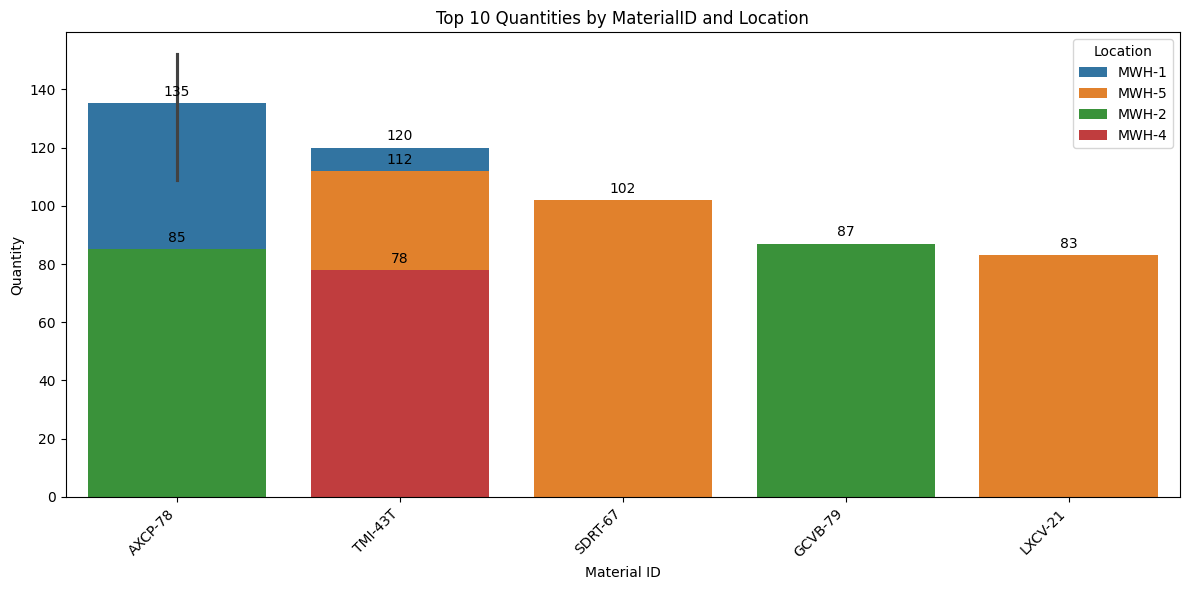

In [ ]:
# Just for practice purpose
import matplotlib.pyplot as plt
import seaborn as sns

# Create a bar plot of the top quantities
plt.figure(figsize=(12, 6))
ax = sns.barplot(x='MaterialID', y='Quantity', hue='Location', data=df_sorted.head(10), dodge=False)
plt.title('Top 10 Quantities by MaterialID and Location')
plt.xlabel('Material ID')
plt.ylabel('Quantity')
plt.xticks(rotation=45, ha='right')

# Add value labels on top of all bar
for container in ax.containers:
    ax.bar_label(container, fmt='%.0f', label_type='edge', padding=3)

plt.tight_layout()
plt.show()

In [ ]:
df_sorted = df.sort_values(['MaterialID','Location','Quantity'])
df_sorted

,MaterialID,Location,Quantity
1,AXCP-78,MWH-1,67
48,AXCP-78,MWH-1,75
25,AXCP-78,MWH-1,109
39,AXCP-78,MWH-1,145
24,AXCP-78,MWH-1,152
46,AXCP-78,MWH-2,85
47,AXCP-78,MWH-3,29
4,AXCP-78,MWH-4,36
3,AXCP-78,MWH-5,65
37,AXCP-78,MWH-5,65


In [ ]:
df_sorted = df.sort_values(['MaterialID','Location','Quantity'],ascending=[True,False,True])
df_sorted

,MaterialID,Location,Quantity
3,AXCP-78,MWH-5,65
37,AXCP-78,MWH-5,65
38,AXCP-78,MWH-5,70
4,AXCP-78,MWH-4,36
47,AXCP-78,MWH-3,29
46,AXCP-78,MWH-2,85
1,AXCP-78,MWH-1,67
48,AXCP-78,MWH-1,75
25,AXCP-78,MWH-1,109
39,AXCP-78,MWH-1,145


In [ ]:
pune = pd.read_excel('CDAC_DataBook.xlsx',sheet_name='Pune')
mumbai = pd.read_excel('CDAC_DataBook.xlsx',sheet_name='Mumbai')
print(pune,mumbai)

      Name      Subject Grade
0   Rakesh       Python     A
1    Manoj     MLPython     C
2  Vaibhav   Statistics     B
3   Hitesh   CommSkills     A
4   Suyash  ProjectMgmt     B
5    Vinod           AI     B        Name     Subject Grade
0   Vaibhav   Six Sigma     A
1   Deepika  Statistics     B
2     Arjun  CommSkills     A
3    Chetan      Python     A
4  Abhishek    MLPython     B
5     Vinod          AI     C


In [ ]:
# this is to merge pune and mumbai on basis of matching row in both dataframe
# This is why we are getting Empty DataFrame
pd.merge(pune,mumbai)

,Name,Subject,Grade


In [ ]:
# on basis common subject (like Join)
pd.merge(pune,mumbai,on='Subject')

,Name_x,Subject,Grade_x,Name_y,Grade_y
0,Rakesh,Python,A,Chetan,A
1,Manoj,MLPython,C,Abhishek,B
2,Vaibhav,Statistics,B,Deepika,B
3,Hitesh,CommSkills,A,Arjun,A
4,Vinod,AI,B,Vinod,C


In [ ]:
# Inner Join
pd.merge(pune,mumbai,on='Subject',how='inner')

,Name_x,Subject,Grade_x,Name_y,Grade_y
0,Rakesh,Python,A,Chetan,A
1,Manoj,MLPython,C,Abhishek,B
2,Vaibhav,Statistics,B,Deepika,B
3,Hitesh,CommSkills,A,Arjun,A
4,Vinod,AI,B,Vinod,C


In [ ]:
# left join
pd.merge(pune,mumbai,on='Subject',how='left')

,Name_x,Subject,Grade_x,Name_y,Grade_y
0,Rakesh,Python,A,Chetan,A
1,Manoj,MLPython,C,Abhishek,B
2,Vaibhav,Statistics,B,Deepika,B
3,Hitesh,CommSkills,A,Arjun,A
4,Suyash,ProjectMgmt,B,NaN,NaN
5,Vinod,AI,B,Vinod,C


In [ ]:
pd.merge(pune,mumbai,on=['Subject','Grade'])

,Name_x,Subject,Grade,Name_y
0,Rakesh,Python,A,Chetan
1,Vaibhav,Statistics,B,Deepika
2,Hitesh,CommSkills,A,Arjun


Null/NaN will get as common output, because Null/NaN will get as output

In [ ]:
new_row = pd.DataFrame([['Omkar']], columns=['Name'])

temp1 = pd.concat([mumbai,new_row],ignore_index=True)
temp2 = pd.concat([pune,new_row],ignore_index=True)
print(temp1)
print(temp2)

       Name     Subject Grade
0   Vaibhav   Six Sigma     A
1   Deepika  Statistics     B
2     Arjun  CommSkills     A
3    Chetan      Python     A
4  Abhishek    MLPython     B
5     Vinod          AI     C
6     Omkar         NaN   NaN
      Name      Subject Grade
0   Rakesh       Python     A
1    Manoj     MLPython     C
2  Vaibhav   Statistics     B
3   Hitesh   CommSkills     A
4   Suyash  ProjectMgmt     B
5    Vinod           AI     B
6    Omkar          NaN   NaN


In [ ]:
pd.merge(temp1,temp2,on='Subject')

,Name_x,Subject,Grade_x,Name_y,Grade_y
0,Deepika,Statistics,B,Vaibhav,B
1,Arjun,CommSkills,A,Hitesh,A
2,Chetan,Python,A,Rakesh,A
3,Abhishek,MLPython,B,Manoj,C
4,Vinod,AI,C,Vinod,B
5,Omkar,NaN,NaN,Omkar,NaN


Duplicated record will get as output

In [ ]:
new_row = pd.DataFrame([mumbai.iloc[0]],columns=['Name','Subject','Grade'])
temp11 =  pd.concat([mumbai,new_row],ignore_index=True)
temp12 = pd.concat([pune,new_row],ignore_index=True)
print(temp11)
print(temp12)

       Name     Subject Grade
0   Vaibhav   Six Sigma     A
1   Deepika  Statistics     B
2     Arjun  CommSkills     A
3    Chetan      Python     A
4  Abhishek    MLPython     B
5     Vinod          AI     C
6   Vaibhav   Six Sigma     A
      Name      Subject Grade
0   Rakesh       Python     A
1    Manoj     MLPython     C
2  Vaibhav   Statistics     B
3   Hitesh   CommSkills     A
4   Suyash  ProjectMgmt     B
5    Vinod           AI     B
6  Vaibhav    Six Sigma     A


In [ ]:
pd.merge(temp11,temp12,on='Subject',how='inner')

,Name_x,Subject,Grade_x,Name_y,Grade_y
0,Vaibhav,Six Sigma,A,Vaibhav,A
1,Deepika,Statistics,B,Vaibhav,B
2,Arjun,CommSkills,A,Hitesh,A
3,Chetan,Python,A,Rakesh,A
4,Abhishek,MLPython,B,Manoj,C
5,Vinod,AI,C,Vinod,B
6,Vaibhav,Six Sigma,A,Vaibhav,A


In [ ]:
pd.merge(pune,mumbai, on='Subject', how='outer')

,Name_x,Subject,Grade_x,Name_y,Grade_y
0,Vinod,AI,B,Vinod,C
1,Hitesh,CommSkills,A,Arjun,A
2,Manoj,MLPython,C,Abhishek,B
3,Suyash,ProjectMgmt,B,NaN,NaN
4,Rakesh,Python,A,Chetan,A
5,NaN,Six Sigma,NaN,Vaibhav,A
6,Vaibhav,Statistics,B,Deepika,B


In [ ]:
pd.merge(temp1,temp2, on='Subject', how='outer')

,Name_x,Subject,Grade_x,Name_y,Grade_y
0,Vinod,AI,C,Vinod,B
1,Arjun,CommSkills,A,Hitesh,A
2,Abhishek,MLPython,B,Manoj,C
3,NaN,ProjectMgmt,NaN,Suyash,B
4,Chetan,Python,A,Rakesh,A
5,Vaibhav,Six Sigma,A,NaN,NaN
6,Deepika,Statistics,B,Vaibhav,B
7,Omkar,NaN,NaN,Omkar,NaN


In [ ]:
# column which are exclusively present in the left side of the dataframe will not be NaN
pd.merge(pune,mumbai, on='Subject', how='left')

,Name_x,Subject,Grade_x,Name_y,Grade_y
0,Rakesh,Python,A,Chetan,A
1,Manoj,MLPython,C,Abhishek,B
2,Vaibhav,Statistics,B,Deepika,B
3,Hitesh,CommSkills,A,Arjun,A
4,Suyash,ProjectMgmt,B,NaN,NaN
5,Vinod,AI,B,Vinod,C
